MATH 60629A
======
Tutoriel : une introduction pratique à l'apprentissage automatique en Python
=============

Imaginez que vous venez d'être embauché·e comme analyste de données dans une entreprise de vélopartage (pensez [BIXI](https://bixi.com/)). L'équipe des opérations vous adresse deux demandes :

1. **Prévoir la demande :** combien de vélos seront loués à une heure donnée? (Cela guide les plans de maintenance et de rééquilibrage des stations.)
2. **Signaler à l'avance les heures de forte demande**, pour que les camions puissent pré-positionner des vélos aux stations achalandées.

La première demande est un problème de **régression**, la seconde un problème de **classification** — précisément les deux familles d'apprentissage supervisé étudiées aux semaines 2 et 3. Dans ce tutoriel, vous résoudrez les deux, sur des données réelles, avec la boîte à outils Python standard :

- **NumPy** — des tableaux de nombres et du calcul rapide sur ceux-ci ([partie 1](#numpy)),
- **pandas** — des tables de données ([partie 2](#pandas)),
- **scikit-learn** — les modèles d'apprentissage automatique eux-mêmes ([parties 3](#regression) et [4](#classification)).

Nos données proviennent de Capital Bikeshare (Washington, DC) : chaque heure d'opération en 2011–2012, accompagnée de la météo et des informations de calendrier de cette heure.

**Comment utiliser ce carnet.**
- Exécutez les cellules une à une, de haut en bas, avec `Shift+Enter`.
- Les exercices sont marqués d'un ✏️. Ils sont courts et conçus pour être faits au fil de la lecture : remplacez les `...` par votre code.
- **La partie 1 (NumPy) est optionnelle** : si les tableaux NumPy vous sont déjà familiers, passez directement à la [partie 2](#pandas).
- Minutage approximatif pour nos 180 minutes : partie 1 (15 min) · partie 2 (30 min) · partie 3 (50 min) · partie 4 (45 min) · partie 5 (30 min).

**Table des matières**
- [Partie 0 — Mise en place](#setup)
- [Partie 1 — NumPy en 15 minutes (optionnelle)](#numpy)
- [Partie 2 — Juste assez de pandas](#pandas)
- [Partie 3 — Régression : prédire la demande horaire](#regression)
- [Partie 4 — Classification : signaler les heures de forte demande](#classification)
- [Partie 5 — Défi : battez notre meilleur modèle](#challenge)
- [Épilogue — Un aperçu de la semaine prochaine](#epilogue)

<a id='setup'></a>
# Partie 0 — Mise en place

Ce carnet fonctionne sur [Google Colab](https://colab.research.google.com/) ou sur votre propre machine. La cellule ci-dessous télécharge les deux fichiers nécessaires (le jeu de données et un petit fichier d'aide pour les graphiques) s'ils ne sont pas déjà présents.

In [1]:
import os
import urllib.request

REPO = 'https://raw.githubusercontent.com/lcharlin/80-629/master/week4-PracticalSession'
for fname in ['bikes.csv', 'local_utils.py']:
    if not os.path.exists(fname):
        urllib.request.urlretrieve(f'{REPO}/{fname}', fname)
        print(f'Téléchargé : {fname}')
print('Mise en place terminée.')

Téléchargé : bikes.csv
Téléchargé : local_utils.py
Mise en place terminée.


Une remarque avant de commencer : ce tutoriel utilise des graphiques pour bâtir l'intuition, mais **apprendre une bibliothèque graphique n'est pas un objectif du cours**. Tout le code de visualisation est caché dans `local_utils.py`; vous ne ferez qu'appeler de petites fonctions d'aide. (Si vous voulez plus tard produire vos propres graphiques, [matplotlib](https://matplotlib.org/stable/tutorials/index.html) est le choix standard.)

*Note :* les données et le code (noms de variables, de colonnes) sont en anglais, comme c'est l'usage presque universel en pratique.

<a id='numpy'></a>
# Partie 1 — NumPy en 15 minutes *(optionnelle)*

> Les tableaux NumPy, le découpage (*slicing*) et les opérations vectorisées vous sont familiers? Passez à la [partie 2](#pandas).

L'apprentissage automatique, mécaniquement parlant, c'est des mathématiques appliquées à de grandes grilles de nombres (vecteurs/matrices). Les listes Python conviennent pour *ranger* des choses, mais restent limitées pour le calcul. **NumPy** fournit le `array` : une grille de nombres sur laquelle le calcul est rapide et concis. Il nous importe pour une grande raison : **le format de données natif de scikit-learn est le tableau NumPy.** Avoir une certaine compréhension de leur fonctionnement vous sera donc utile.

In [2]:
import numpy as np

temperatures = [12.5, 15.0, 21.3, 8.4]   # une liste Python ordinaire
arr = np.array(temperatures)              # ... convertie en tableau NumPy
arr

array([12.5, 15. , 21.3,  8.4])

**Opérations vectorisées.** Avec un tableau, une opération mathématique s'applique à *tous* les éléments d'un coup — aucune boucle `for` nécessaire. C'est à la fois plus rapide et plus lisible.

In [3]:
print(arr * 2)            # double chaque élément
print(arr * 9/5 + 32)     # convertit chaque température en Fahrenheit

[25.  30.  42.6 16.8]
[54.5  59.   70.34 47.12]


**La forme (`shape`).** Chaque tableau a une `shape`. Un tableau à 2 dimensions est une matrice, et l'apprentissage automatique a une convention universelle à son sujet :

$$\underbrace{\text{lignes}}_{\text{exemples}} \times \underbrace{\text{colonnes}}_{\text{caractéristiques}}$$

Un tableau de forme `(17379, 58)` contient donc 17 379 exemples décrits chacun par 58 caractéristiques (*features*). Vous verrez cette convention partout dans scikit-learn, écrite `(n_samples, n_features)`.

In [4]:
# 4 exemples (lignes), 3 caractéristiques chacun (température, humidité, vent)
data = np.array([[12.5, 60, 10.2],
                 [15.0, 55,  8.1],
                 [21.3, 40,  5.5],
                 [ 8.4, 80, 15.0]])
data.shape

(4, 3)

**Indexation et découpage.** Les crochets sélectionnent des parties d'un tableau : `data[i]` est la ligne `i`, `data[:, j]` la colonne `j` (lisez `:` comme « toutes les lignes »), et `data[i:k]` les lignes `i` à `k` exclusivement. Python compte à partir de 0.

In [5]:
print('première ligne   :', data[0])
print('première colonne :', data[:, 0])
print('lignes 1 et 2    :')
print(data[1:3])

première ligne   : [12.5 60.  10.2]
première colonne : [12.5 15.  21.3  8.4]
lignes 1 et 2    :
[[15.  55.   8.1]
 [21.3 40.   5.5]]


**Masques booléens.** Comparer un tableau à une valeur donne un tableau de `True`/`False`. Un tel *masque* permet de sélectionner des éléments, et sa moyenne est la *proportion* de `True` — une petite astuce que vous utiliserez constamment.

In [6]:
temps = data[:, 0]
warm = temps > 14
print('masque                          :', warm)
print('températures chaudes            :', temps[warm])
print("proportion d'heures chaudes     :", warm.mean())

masque                          : [False  True  True False]
températures chaudes            : [15.  21.3]
proportion d'heures chaudes     : 0.5


**Agrégations.** Les tableaux savent se résumer eux-mêmes : `.mean()`, `.max()`, `.sum()`, `.argmax()` (la *position* du maximum)... Sur un tableau 2D, `axis=0` agrège le long des colonnes (un résultat par caractéristique).

In [7]:
print('moyenne de tout          :', data.mean())
print('moyenne de chaque colonne:', data.mean(axis=0))

moyenne de tout          : 27.583333333333332
moyenne de chaque colonne: [14.3  58.75  9.7 ]


### ✏️ Exercice 1

Le tableau ci-dessous contient le nombre de locations pour chacune des 24 heures d'une journée (heure 0 à heure 23). Calculez :

a) le nombre moyen de locations sur la journée;
b) l'heure la plus achalandée de la journée (*indice :* `.argmax()`);
c) la proportion d'heures comptant au moins 300 locations;
d) le nombre total de locations pendant la pointe du soir, de 17 h à 19 h inclusivement (*indice :* le découpage).

In [11]:
# --- Exercice 1 ---
day = np.array([41, 18, 11, 4, 3, 22, 90, 320, 512, 275, 180, 210,
                260, 254, 240, 265, 340, 590, 540, 380, 250, 190, 140, 80])

avg_rentals = day.mean()
busiest_hour = day.argmax()
prop_high = (day>300).mean()
evening_rush = day[18:20].sum()

print(f'Locations moyennes par heure    : {avg_rentals}')
print(f'Heure la plus achalandée        : {busiest_hour} h')
print(f"Proportion d'heures >= 300      : {prop_high}")
print(f'Total des locations de 17 à 19 h: {evening_rush}')

Locations moyennes par heure    : 217.29166666666666
Heure la plus achalandée        : 17 h
Proportion d'heures >= 300      : 0.25
Total des locations de 17 à 19 h: 920


NumPy va beaucoup plus loin (algèbre linéaire, nombres aléatoires, *broadcasting*...), mais c'est tout ce qu'il nous faut aujourd'hui. Référence : le [guide de démarrage NumPy](https://numpy.org/doc/stable/user/quickstart.html) (en anglais).

<a id='pandas'></a>
# Partie 2 — Juste assez de pandas

**pandas** est la bibliothèque standard pour les tables de données — pensez à un chiffrier dans Python. Son objet central est le `DataFrame` : une table aux colonnes nommées, construite au-dessus de tableaux NumPy.

pandas est une *très* grosse bibliothèque, dans laquelle il est facile d'engloutir des heures. Nous resterons délibérément en surface et n'apprendrons que les six opérations dont un·e analyste a constamment besoin :

charger → regarder → sélectionner → filtrer → résumer → encoder.

(Référence pour plus tard : [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html).)

In [12]:
import pandas as pd

df = pd.read_csv('bikes.csv')   # charge une table depuis un fichier csv
df.head()                       # affiche les premières lignes

,date,season,year,month,hour,weekday,workingday,holiday,weather,temp,feels_like,humidity,windspeed,rentals
0,2011-01-01,winter,2011,jan,0,saturday,0,0,clear,9.8,14.4,81,0.0,16
1,2011-01-01,winter,2011,jan,1,saturday,0,0,clear,9.0,13.6,80,0.0,40
2,2011-01-01,winter,2011,jan,2,saturday,0,0,clear,9.0,13.6,80,0.0,32
3,2011-01-01,winter,2011,jan,3,saturday,0,0,clear,9.8,14.4,75,0.0,13
4,2011-01-01,winter,2011,jan,4,saturday,0,0,clear,9.8,14.4,75,0.0,1


Chaque ligne est **une heure d'opération** du système de vélopartage. Les colonnes :

| Colonne | Signification |
|---|---|
| `date`, `year`, `month`, `hour`, `weekday` | quand |
| `season` | winter / spring / summer / fall |
| `workingday`, `holiday` | 1 si jour ouvrable / férié, 0 sinon |
| `weather` | clear (dégagé) / mist (brume) / light_rain_snow / heavy_rain_snow |
| `temp`, `feels_like` | température et température ressentie (°C) |
| `humidity` | humidité relative (%) |
| `windspeed` | vitesse du vent (km/h) |
| **`rentals`** | **nombre de vélos loués cette heure-là — ce que nous voulons prédire** |

In [13]:
print(f'La table compte {df.shape[0]} lignes (heures) et {df.shape[1]} colonnes.')

La table compte 17379 lignes (heures) et 14 colonnes.


`.describe()` résume les colonnes numériques — toujours un bon premier réflexe devant un nouveau jeu de données.

In [14]:
df.describe().round(1)

,year,hour,workingday,holiday,temp,feels_like,humidity,windspeed,rentals
count,17379.0,17379.0,17379.0,17379.0,17379.0,17379.0,17379.0,17379.0,17379.0
mean,2011.5,11.5,0.7,0.0,20.4,23.8,62.7,12.7,189.5
std,0.5,6.9,0.5,0.2,7.9,8.6,19.3,8.2,181.4
min,2011.0,0.0,0.0,0.0,0.8,0.0,0.0,0.0,1.0
25%,2011.0,6.0,0.0,0.0,13.9,16.7,48.0,7.0,40.0
50%,2012.0,12.0,1.0,0.0,20.5,24.2,63.0,13.0,142.0
75%,2012.0,18.0,1.0,0.0,27.1,31.1,78.0,17.0,281.0
max,2012.0,23.0,1.0,1.0,41.0,50.0,100.0,57.0,977.0


Quelques observations dignes de mention : une heure moyenne compte environ **189 locations**, mais la dispersion est énorme (de 1 à 977); les températures vont de −8 °C à 41 °C. Se faire une idée de ces ordres de grandeur maintenant nous aidera à juger nos modèles plus tard.

**Sélectionner des colonnes.** Des crochets simples avec un nom donnent une colonne (une `Series`); une liste de noms donne un `DataFrame` plus petit.

In [15]:
df['rentals'].head()

,rentals
0,16
1,40
2,32
3,13
4,1


In [16]:
df[['date', 'hour', 'rentals']].head()

,date,hour,rentals
0,2011-01-01,0,16
1,2011-01-01,1,40
2,2011-01-01,2,32
3,2011-01-01,3,13
4,2011-01-01,4,1


**Filtrer des lignes.** Exactement l'astuce des masques booléens de NumPy : une condition sur une colonne produit des valeurs `True`/`False`, et `df[masque]` conserve les lignes où le masque vaut `True`. On combine les conditions avec `&` (et) / `|` (ou), chacune entre parenthèses.

In [17]:
rainy = df[df['weather'] == 'light_rain_snow']
print(f'{len(rainy)} heures de pluie/neige sur {len(df)}')

# heures chaudes ET très achalandées
df[(df['temp'] > 30) & (df['rentals'] > 600)].head()

1419 heures de pluie/neige sur 17379


,date,season,year,month,hour,weekday,workingday,holiday,weather,temp,feels_like,humidity,windspeed,rentals
3379,2011-05-25,spring,2011,may,17,wednesday,1,0,clear,30.3,33.3,51,15.0,601
3883,2011-06-15,spring,2011,jun,17,wednesday,1,0,clear,30.3,32.6,28,7.0,638
4171,2011-06-27,summer,2011,jun,17,monday,1,0,clear,30.3,34.1,55,9.0,604
5564,2011-08-24,summer,2011,aug,18,wednesday,1,0,clear,30.3,34.1,55,20.0,621
11196,2012-04-16,spring,2012,apr,17,monday,0,1,clear,32.8,34.8,33,26.0,712


**Résumer.** `value_counts()` compte les catégories; `groupby()` répond à la question d'affaires essentielle « quelle est la moyenne de Y pour chaque valeur de X? ».

In [18]:
df['weather'].value_counts()

,count
weather,
clear,11413
mist,4544
light_rain_snow,1419
heavy_rain_snow,3


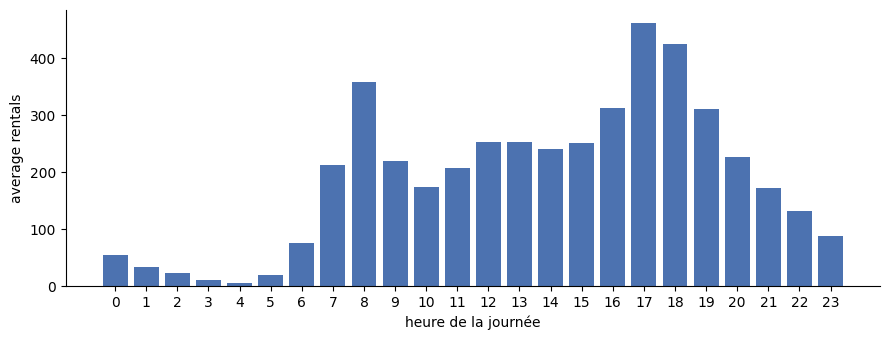

In [19]:
avg_by_hour = df.groupby('hour')['rentals'].mean()

from local_utils import plot_avg_rentals
plot_avg_rentals(avg_by_hour, xlabel='heure de la journée')

Ce seul graphique contient déjà une vraie information d'affaires : deux pics marqués, à 8 h et à 17–18 h — **les navetteurs**. Gardez cette forme en tête; elle comptera au moment de modéliser.

### ✏️ Exercice 2

a) Calculez les locations moyennes pour chaque type de `weather`. L'ordre obtenu correspond-il à votre intuition?
b) Calculez les locations moyennes les jours ouvrables et non ouvrables (`workingday`).
c) *Boni :* trouvez l'heure la plus achalandée de tout le jeu de données — affichez sa ligne complète (*indice :* `.sort_values()` ou `.idxmax()` combiné à `.loc`).

In [20]:
# --- Exercice 2 ---
avg_by_weather = df.groupby('weather')['rentals'].mean()
avg_by_workingday = df.groupby('workingday')['rentals'].mean()

print(avg_by_weather)
print(avg_by_workingday)

# Boni
busiest_row = df.sort_values('rentals', ascending=False).iloc[0]
busiest_row

weather
clear              204.869272
heavy_rain_snow     74.333333
light_rain_snow    111.579281
mist               175.165493
Name: rentals, dtype: float64
workingday
0    181.405332
1    193.207754
Name: rentals, dtype: float64


,14773
date,2012-09-12
season,summer
year,2012
month,sep
hour,18
weekday,wednesday
workingday,1
holiday,0
weather,clear
temp,27.1


**Encoder les catégories en nombres.** Les modèles calculent avec des nombres; ils ne peuvent pas multiplier `'clear'` par un coefficient. Le remède standard, vu en classe, est la **variable indicatrice** (*dummy*, encodage *one-hot*) : une colonne 0/1 par catégorie. Avec pandas, c'est une seule ligne, `pd.get_dummies` :

In [21]:
pd.get_dummies(df[['weather']]).head()

,weather_clear,weather_heavy_rain_snow,weather_light_rain_snow,weather_mist
0,True,False,False,False
1,True,False,False,False
2,True,False,False,False
3,True,False,False,False
4,True,False,False,False


### ✏️ Question 3 *(discussion — sans code)*

Nous encoderons aussi `hour` en 24 variables indicatrices, même si c'est déjà un nombre. Regardez de nouveau le graphique des locations moyennes par heure. **Pourquoi ne pas simplement garder `hour` comme une seule caractéristique numérique dans un modèle linéaire?**

En encodant en variable numérique, on force le modèle de regréssion trouver un lien linéaire unique entre les différente heures, ce qui pourrait dégrader la qualité du modèle. En encodant en variable binaire, on capture mieux les interactions de chaque heure avec la variable cible et sûrement mieux les vraies différences entre les heures.

In [ ]:
df_model = pd.get_dummies(df, columns=['season', 'month', 'hour',
                                       'weekday', 'weather'])
print(f'Avant encodage : {df.shape[1]} colonnes. Après : {df_model.shape[1]} colonnes.')
df_model.head()

Une dernière connexion : sous le capot, pandas, c'est du NumPy. `.values` révèle le tableau brut derrière toute colonne ou table — c'est là-dessus que scikit-learn calculera réellement (il accepte volontiers les DataFrames directement et fait la conversion pour nous).

In [ ]:
df_model['temp'].values[:5]

<a id='regression'></a>
# Partie 3 — Régression : prédire la demande horaire

Nous pouvons maintenant poser le problème d'apprentissage supervisé de la semaine 2 : un jeu de données de paires $(x_i, y_i)$, où $x_i$ décrit l'heure $i$ (ses caractéristiques) et $y_i$ est le nombre de locations pendant cette heure. Par convention, les caractéristiques sont rassemblées dans une matrice `X` (une ligne par exemple — la convention NumPy de la partie 1) et les cibles dans un vecteur `y`.

In [ ]:
X = df_model.drop(columns=['date', 'rentals'])   # tout sauf la cible (et la date brute)
y = df_model['rentals']
print(X.shape, y.shape)

### 3.1 — Séparation entraînement/test

L'objectif de l'apprentissage supervisé est de bien prédire sur des données que le modèle n'a **jamais vues** (semaine 2 : la *généralisation*). Nous mettons donc de côté 20 % de nos données comme **ensemble de test**, intouché pendant l'entraînement et utilisé seulement pour estimer la performance à la toute fin.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)   # random_state rend le mélange reproductible

print(f"{len(X_train)} exemples d'entraînement, {len(X_test)} exemples de test")

*Remarque pour les curieux :* nos lignes sont des heures consécutives, si bien qu'une séparation aléatoire place dans l'ensemble de test des heures dont les voisines immédiates sont dans l'entraînement — ce qui rend le test légèrement optimiste. L'évaluation rigoureuse des séries temporelles (entraîner sur le passé, tester sur le futur) est un sujet en soi; nous le laissons de côté aujourd'hui.

### 3.2 — Toujours commencer par un modèle de référence

Avant tout modèle sophistiqué, ajustons-en un trivial : **prédire la moyenne de l'ensemble d'entraînement pour chaque heure**. Un modèle incapable de battre cette référence (*baseline*) n'a rien appris. scikit-learn la fournit sous le nom de `DummyRegressor`.

Pour mesurer l'erreur, nous utilisons l'**erreur quadratique moyenne (MSE)** vue en classe, et rapportons aussi sa racine carrée (**RMSE**), qui vit dans les unités d'origine. C.-à-d. « nous nous trompons d'environ autant de locations ».

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

baseline = DummyRegressor(strategy='mean') # prédit la moyenne de l'entraînement pour chaque exemple de test
baseline.fit(X_train, y_train)

# une petite fonction d'aide que nous réutiliserons pour chaque modèle
def rmse(model, X, y):
    return mean_squared_error(y, model.predict(X)) ** 0.5

print(f'Référence — RMSE entraînement : {rmse(baseline, X_train, y_train):.1f} locations')
print(f'Référence — RMSE test         : {rmse(baseline, X_test, y_test):.1f} locations')

Une erreur d'environ 180 locations sur une heure typique : voilà le chiffre à battre.

### 3.3 — Le patron scikit-learn

Vous venez de le voir avec la référence. **Chaque** modèle de scikit-learn suit les trois mêmes étapes :

```python
model = SomeModel()          # 1. créer (en choisissant les hyperparamètres)
model.fit(X_train, y_train)  # 2. apprendre les paramètres des données d'entraînement
model.predict(X_new)         # 3. prédire sur de nouvelles données
```

Le reste de ce tutoriel — et une grande partie de l'apprentissage automatique appliqué — n'est que variations sur ces trois lignes. Utilisons-les sur la régression linéaire vue en classe :

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train, y_train)

print(f'Régression linéaire — RMSE entraînement : {rmse(reg, X_train, y_train):.1f}')
print(f'Régression linéaire — RMSE test         : {rmse(reg, X_test, y_test):.1f}')

Deux observations :
- Le RMSE de test passe de ~178 à ~100 : nos caractéristiques portent un vrai signal.
- Les erreurs d'entraînement et de test sont presque égales : **aucun surapprentissage** ici. Avec ~13 900 exemples d'entraînement pour 59 paramètres, le modèle n'a pas la capacité de mémoriser (la discussion biais/variance de la semaine 2).

Nous pouvons regarder les prédictions directement :

In [ ]:
from local_utils import plot_predictions
plot_predictions(y_test, reg.predict(X_test))

### 3.4 — Qu'a appris le modèle?

Un modèle linéaire prédit $f(x) = w \cdot x + b$. Les poids appris $w$ (`reg.coef_`) contiennent l'information apprise. En les analysant, attention : ils ne peuvent être comparés que si les caractéristiques vivent sur des échelles comparables, et chacun se lit « toutes choses égales par ailleurs ».

In [ ]:
coefs = pd.Series(reg.coef_, index=X.columns).sort_values()
print('Effets les plus négatifs :')
print(coefs.head(5).round(1))
print()
print('Effets les plus positifs :')
print(coefs.tail(5).round(1))

Le modèle a redécouvert, à partir des seules données, ce que la plupart des équipes d'opérations savent sans doute déjà : les heures de pointe (17 h, 18 h, 8 h) gonflent la demande; la nuit et le mauvais temps la font baisser. Cette interprétabilité est une raison majeure pour laquelle les modèles linéaires restent omniprésents en analytique d'affaires (c.-à-d. que les modèles non linéaires peuvent être plus difficiles, voire presque impossibles, à interpréter).

Vérifions aussi une prédiction individuelle contre la réalité :

In [ ]:
i = 3                              # choisissez n'importe quel exemple de test
row_id = X_test.index[i]

print("L'heure que nous prédisons :")
print(df.loc[row_id, ['date', 'weekday', 'hour', 'weather', 'temp']])
print()
print(f'Locations réelles    : {y_test.iloc[i]}')
print(f'Prédiction du modèle : {reg.predict(X_test.iloc[[i]])[0]:.0f}')

### ✏️ Exercice 4

Selon le modèle, combien de locations supplémentaires par heure apporte un degré Celsius de plus, toutes choses égales par ailleurs? Extrayez la réponse de `coefs`, et vérifiez que son signe concorde avec l'intuition bâtie à l'exercice 2.

In [ ]:
# --- Exercice 4 ---
temp_effect = ...
print(f'Chaque degré Celsius supplémentaire est associé à {temp_effect:.1f} locations de plus par heure.')

### 3.5 — Le surapprentissage : et si le service venait d'être lancé?

Notre modèle se comporte bien en partie parce que les données abondent. Les entreprises sont rarement aussi chanceuses à leurs débuts. Supposons que le service ait été lancé il y a une semaine, et que nous ne disposions que de 168 heures de données :

In [ ]:
X_small, y_small = X_train[:168], y_train[:168]   # une semaine d'heures

reg_small = LinearRegression()
reg_small.fit(X_small, y_small)

print(f'RMSE entraînement (sur les 168 heures) : {rmse(reg_small, X_small, y_small):.1f}')
print(f'RMSE test                              : {rmse(reg_small, X_test, y_test):.1f}')

Un écart important est apparu : bien meilleur sur les données d'entraînement que sur les nouvelles données. C'est le **surapprentissage**, exactement tel que défini à la semaine 2 — le modèle a en partie mémorisé le bruit de ses 168 exemples au lieu de n'apprendre que le patron général.

### ✏️ Question 5 *(discussion — sans code)*

Combien de paramètres ce modèle linéaire compte-t-il? (*Indice :* n'oubliez pas l'ordonnée à l'origine.) Comparez ce nombre au nombre d'exemples d'entraînement. En quoi cette comparaison explique-t-elle ce que nous venons d'observer?

### 3.6 — La régularisation à la rescousse

Le remède de la semaine 2 : **pénaliser les grands poids**. La *régression ridge*, c'est la régression linéaire plus une pénalité L2 $\alpha \sum_j w_j^2$ ajoutée à l'objectif d'entraînement. L'hyperparamètre $\alpha$ en règle la force : $\alpha = 0$ redonne la régression linéaire ordinaire; $\alpha \to \infty$ écrase tous les poids vers 0 (et le modèle vers la référence).

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1)
ridge.fit(X_small, y_small)

print(f'Ridge (alpha=1) — RMSE entraînement : {rmse(ridge, X_small, y_small):.1f}')
print(f'Ridge (alpha=1) — RMSE test         : {rmse(ridge, X_test, y_test):.1f}')

L'erreur d'entraînement a un peu *empiré*, l'erreur de test s'est *améliorée*. Mais nous avons choisi $\alpha=1$ au hasard. Balayons une plage de valeurs et observons les deux erreurs :

In [ ]:
alphas = np.logspace(-2, 4, 13)   # 0.01, ..., 10000 (puissances de 10)

train_errors, test_errors = [], []
for a in alphas:
    r = Ridge(alpha=a).fit(X_small, y_small)
    train_errors.append(rmse(r, X_small, y_small))
    test_errors.append(rmse(r, X_test, y_test))

from local_utils import plot_train_test
plot_train_test(alphas, train_errors, test_errors,
                xlabel='alpha (échelle log)', ylabel='RMSE', logx=True)

Cette image *est* le compromis biais/variance, tracé par des données réelles :

- **À gauche** (α minuscule) : erreur d'entraînement basse, erreur de test plus haute — surapprentissage (haute variance).
- **À droite** (α énorme) : les deux erreurs sont hautes — sous-apprentissage (haut biais). (Avec un α gigantesque, tous les poids sont écrasés à zéro et nous revoilà... à la référence.)
- L'erreur de test est en forme de U; le point idéal se trouve au milieu, autour de $\alpha \approx 1$.

*(Aparté technique : par convention, on balaie les valeurs d'hyperparamètres en puissances de 10, d'où `np.logspace`.)*

### 3.7 — Choisir $\alpha$ honnêtement : la validation croisée

Nous venons de choisir $\alpha$ en regardant l'erreur de **test** — un péché méthodologique. L'ensemble de test doit rester sous clé jusqu'à l'évaluation finale; sinon il devient silencieusement une partie de l'entraînement et cesse d'être une mesure honnête (semaine 2 : la *validation de modèles*).

La procédure correcte est la **validation croisée à l'intérieur des données d'entraînement**. scikit-learn l'automatise : `RidgeCV` essaie chaque valeur candidate de $\alpha$ par validation croisée interne sur l'ensemble d'entraînement et retient la meilleure.

### ✏️ Exercice 6

Ajustez un `RidgeCV` (déjà importé ci-dessous) sur le *petit* ensemble d'entraînement, en lui passant notre grille `alphas`. Affichez le $\alpha$ retenu (attribut `.alpha_`) et son RMSE de test.

In [ ]:
# --- Exercice 6 ---
from sklearn.linear_model import RidgeCV

ridge_cv = ...

print(f'alpha retenu par validation croisée : {ridge_cv.alpha_}')
print(f'RMSE test : {rmse(ridge_cv, X_test, y_test):.1f}')

Enfin, revenons à l'ensemble d'entraînement **complet** :

In [ ]:
ridge_cv_full = RidgeCV(alphas=alphas)
ridge_cv_full.fit(X_train, y_train)

print(f'alpha retenu : {ridge_cv_full.alpha_}')
print(f'RMSE test : {rmse(ridge_cv_full, X_test, y_test):.1f}')

Quand les données abondent, la régularisation ne change presque rien (RMSE de test ~100 dans les deux cas) — les données elles-mêmes contraignent le modèle. Une leçon à retenir : **plus de données est souvent le meilleur régularisateur.**

### Où en sommes-nous

| Modèle | RMSE test |
|---|---|
| Référence (prédire la moyenne) | ~178 |
| Régression linéaire (données complètes) | ~100 |
| RidgeCV (données complètes) | ~100 |
| Régression linéaire (une semaine de données) | ~123 |
| RidgeCV (une semaine de données) | ~119 |

<a id='classification'></a>
# Partie 4 — Classification : signaler les heures de forte demande

Deuxième demande de l'équipe des opérations : un système qui signale, à l'avance, les heures où la demande sera **forte** — disons au moins 300 locations (grosso modo le quart supérieur des heures) — pour que les camions pré-positionnent des vélos.

La cible est maintenant une **classe** (forte demande : oui/non) plutôt qu'une quantité : c'est la *classification*, le cadre de la semaine 3. Les caractéristiques `X` ne changent pas; seul `y` change.

In [ ]:
y_class = (df['rentals'] >= 300).astype(int)   # 1 = forte demande, 0 = normale
print(f"Part des heures de forte demande : {y_class.mean():.1%}")

X_train, X_test, yc_train, yc_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42)

### 4.1 — La référence, encore

La mesure d'erreur naturelle est maintenant l'**exactitude** (*accuracy*) : la proportion de prédictions correctes. Et de nouveau, commençons par un modèle trivial : **toujours prédire la classe la plus fréquente** (« demande normale »).

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_clf = DummyClassifier(strategy='most_frequent')
baseline_clf.fit(X_train, yc_train)

acc = accuracy_score(yc_test, baseline_clf.predict(X_test))
print(f'Exactitude de la référence : {acc:.1%}')

**78,5 % d'exactitude en étant parfaitement inutile** — il ne signale jamais la moindre heure de forte demande! C'est le piège classique de l'exactitude avec des classes déséquilibrées. Deux leçons : toujours se comparer à cette référence, et toujours regarder *où* se trouvent les erreurs (nous le ferons dans un instant).

### 4.2 — La régression logistique

Le classifieur linéaire de la semaine 3 : calculer un score linéaire $w \cdot x + b$, l'écraser par la fonction logistique (sigmoïde) en une probabilité, prédire « forte demande » quand cette probabilité dépasse 50 %. Les trois mêmes lignes que toujours :

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=5000)   # laisser à l'optimiseur assez d'itérations
log_reg.fit(X_train, yc_train)

print(f'exactitude entraînement : {accuracy_score(yc_train, log_reg.predict(X_train)):.1%}')
print(f'exactitude test         : {accuracy_score(yc_test, log_reg.predict(X_test)):.1%}')

Un net bond au-dessus de la référence. Et comme le modèle produit des *probabilités*, l'entreprise peut régler son propre compromis — n'envoyer les camions que lorsqu'il est très sûr, par exemple :

In [ ]:
probs = log_reg.predict_proba(X_test[:5])
pd.DataFrame(probs.round(3), columns=['P(normale)', 'P(forte demande)'])

### 4.3 — La matrice de confusion : où sont les erreurs?

Pour un classifieur, un seul chiffre d'exactitude cache l'information d'affaires la plus importante : **quels types** d'erreurs il commet. La matrice de confusion croise les classes réelles et prédites (calculée ici avec le `crosstab` de pandas, que vous connaissez maintenant) :

In [ ]:
y_pred = log_reg.predict(X_test)
pd.crosstab(yc_test.values, y_pred,
            rownames=['réel'], colnames=['prédit'])

Les deux types d'erreurs ont des coûts très différents :
- **Heures de forte demande manquées** (réel 1, prédit 0) : des stations se vident, des clients repartent à pied.
- **Fausses alertes** (réel 0, prédit 1) : des camions se déplacent pour rien.

L'exactitude leur donne le même poids; votre équipe d'opérations, très probablement pas. Quantifier cette distinction (précision, rappel) est la pratique courante — gardez le vocabulaire en tête pour vos projets.

### 4.4 — Les k plus proches voisins (et pourquoi l'échelle compte)

Le classifieur le plus intuitif de la semaine 3 : pour classer une nouvelle heure, trouver les $k$ heures les plus *semblables* dans les données d'entraînement et procéder à un vote majoritaire.

« Semblable » signifie *proche en distance* — et cela crée une subtilité. Nos caractéristiques vivent sur des échelles très différentes : l'humidité court de 0 à 100 tandis que les indicatrices valent 0/1. Telle quelle, la distance est dominée par les caractéristiques aux plus grands nombres. Le remède standard est de **standardiser** chaque caractéristique (soustraire sa moyenne, diviser par son écart-type), avec `StandardScaler`. Notez que le standardiseur est ajusté sur les données d'*entraînement* seulement — le même principe « sans tricher » que la validation croisée.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)                        # apprend moyennes et écarts-types sur l'ENTRAÎNEMENT seulement
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_s, yc_train)

print(f'k=1 — exactitude entraînement : {accuracy_score(yc_train, knn1.predict(X_train_s)):.1%}')
print(f'k=1 — exactitude test         : {accuracy_score(yc_test, knn1.predict(X_test_s)):.1%}')

### ✏️ Question 7 *(discussion — sans code)*

Pourquoi l'exactitude d'entraînement du 1-plus-proche-voisin est-elle **exactement 100 %**? Que cela nous dit-il sur le modèle?

In [ ]:
ks = [1, 3, 5, 9, 15, 25, 51]

train_accs, test_accs = [], []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, yc_train)
    train_accs.append(accuracy_score(yc_train, knn.predict(X_train_s)))
    test_accs.append(accuracy_score(yc_test, knn.predict(X_test_s)))

plot_train_test(ks, train_accs, test_accs, xlabel='k (nombre de voisins)',
                ylabel='exactitude')

La même histoire que le balayage de $\alpha$ à la partie 3, en miroir (plus haut est meilleur, maintenant) : un petit $k$ surapprend, un grand $k$ sous-apprend, le point idéal est entre les deux (~$k=15$, environ 91 % — notre meilleur modèle jusqu'ici). $k$ joue pour kNN le rôle que $\alpha$ jouait pour ridge : **un bouton qui contrôle la capacité du modèle**, à régler par validation.

### ✏️ Exercice 8

Ajustez un kNN avec $k = 15$ sur les caractéristiques **non standardisées** (`X_train` au lieu de `X_train_s`) et comparez son exactitude de test. Quelle différence la standardisation a-t-elle faite?

In [ ]:
# --- Exercice 8 ---
knn_unscaled = ...

acc_unscaled = ...
print(f'exactitude test sans standardisation : {acc_unscaled:.1%}')

### 4.5 — Bayes naïf

Le classifieur probabiliste de la semaine 3 : modéliser $p(x \mid y)$ pour chaque classe sous l'hypothèse « naïve » que les caractéristiques sont indépendantes sachant la classe, puis classer avec la règle de Bayes. Ses vertus : la vitesse et la simplicité.

scikit-learn offre une variante par type de caractéristique (gaussienne pour le continu, Bernoulli pour le binaire, catégorielle pour les catégories). La plupart de nos colonnes sont des indicatrices 0/1 : utilisons donc `BernoulliNB` sur celles-là seulement :

In [ ]:
from sklearn.naive_bayes import BernoulliNB

numeric_cols = ['temp', 'feels_like', 'humidity', 'windspeed', 'year']
Xb_train = X_train.drop(columns=numeric_cols)   # ne garder que les colonnes 0/1
Xb_test = X_test.drop(columns=numeric_cols)

nb = BernoulliNB()
nb.fit(Xb_train, yc_train)

print(f'exactitude entraînement : {accuracy_score(yc_train, nb.predict(Xb_train)):.1%}')
print(f'exactitude test         : {accuracy_score(yc_test, nb.predict(Xb_test)):.1%}')

~83 % en s'entraînant en quelques millisecondes — remarquablement proche de la régression logistique, alors même que l'hypothèse d'indépendance est manifestement fausse ici (l'heure et le jour ouvrable, la saison et le mois...). Cette résilience est la raison pour laquelle la semaine 3 présentait Bayes naïf comme une référence simple et solide.

*Boni pour les curieux :* essayez plutôt `GaussianNB` sur **toutes** les caractéristiques. Vous obtiendrez ~59 % — pire que la référence qui ne fait rien! Une gaussienne est un modèle absurde pour des caractéristiques 0/1; un rappel utile que les hypothèses d'un modèle doivent à peu près correspondre aux données.

### Où en sommes-nous

| Classifieur | Exactitude test |
|---|---|
| Référence (toujours « normale ») | 78,5 % |
| Bayes naïf (Bernoulli, indicatrices seulement) | ~83 % |
| Régression logistique | ~86 % |
| kNN ($k=15$, standardisé) | ~91 % |

Une question de clôture qui mérite réflexion : pourquoi kNN bat-il la régression logistique ici? Une réponse : kNN peut capturer des **interactions** — p. ex., 8 h est une heure de pointe *seulement les jours ouvrables* — qu'un score linéaire ne peut pas exprimer... à moins que nous ne construisions ces caractéristiques nous-mêmes. Ce qui nous mène au défi.

<a id='challenge'></a>
# Partie 5 — ✏️ Défi : battez notre meilleur modèle

À votre tour de jouer l'analyste. **Objectif : battre le RMSE de test de ~100** obtenu par `RidgeCV` sur les données complètes (partie 3.7).

Vous pouvez changer tout ce qui se trouve en amont du modèle — c'est ce qu'on appelle l'**ingénierie des caractéristiques** (*feature engineering*), et c'est là que *votre* connaissance du domaine (l'avantage comparatif d'une formation en gestion!) entre dans l'apprentissage automatique. Des idées :

- **Interactions :** le profil horaire diffère entre jours ouvrables et non ouvrables. Créez une caractéristique catégorielle combinée, p. ex. `df['hour'].astype(str) + '_' + df['workingday'].astype(str)`, et laissez `get_dummies` l'encoder.
- Des transformations non linéaires des caractéristiques numériques : `temp` au carré (le confort plafonne aux températures douces?), des tranches de température...
- Tout ce que vous suggère une exploration à la manière de l'exercice 2.

**Règles du jeu :** faites tous vos choix avec les données d'entraînement; n'évaluez sur l'ensemble de test qu'une seule fois, à la fin. Gardez `random_state=42` dans la séparation pour que les résultats soient comparables dans la classe.

In [ ]:
# --- Exercice 9 (défi) ---
df_new = df.copy()

# --- créez votre ou vos nouvelles caractéristiques ici ---
...

# --- puis encodez, séparez, ajustez, évaluez ---
df_new_model = pd.get_dummies(df_new, columns=[...])
X_new = df_new_model.drop(columns=['date', 'rentals'])

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42)

challenge_model = ...

print(f'RMSE test : {rmse(challenge_model, Xn_test, yn_test):.1f}  (objectif : sous 100)')

<a id='epilogue'></a>
# Épilogue — Un aperçu de la semaine prochaine *(optionnel)*

Nous venons de voir que fabriquer à la main la bonne caractéristique (une interaction) bat le réglage de modèles. Le sujet de la semaine prochaine — les **réseaux de neurones** — propose un marché différent : des modèles qui *apprennent* eux-mêmes les non-linéarités et les interactions, directement des caractéristiques brutes, au prix de l'interprétabilité et d'hyperparamètres plus nombreux.

En guise d'avant-goût, en voici un — avec exactement les trois lignes que vous connaissez maintenant par cœur :

In [ ]:
from sklearn.neural_network import MLPRegressor

nn = MLPRegressor(hidden_layer_sizes=(50,), early_stopping=True,
                  max_iter=1000, random_state=0)
nn.fit(scaler.transform(X_train), y_train)     # les réseaux de neurones préfèrent aussi des entrées standardisées

print(f'Réseau de neurones — RMSE test : {rmse(nn, scaler.transform(X_test), y_test):.1f}')

Meilleur que tout ce qui précède — *sans* que nous ayons fabriqué la moindre caractéristique. Comment, et à quel prix? On se voit mercredi.

# En résumé

Vous savez maintenant, sur un vrai jeu de données :
- charger et explorer une table de données avec **pandas** (sélectionner, filtrer, `groupby`);
- préparer des caractéristiques pour la modélisation (`get_dummies`), en comprenant les tableaux dessous (**NumPy**);
- suivre le patron universel de **scikit-learn** — `fit`, `predict`, évaluer — en régression comme en classification;
- pratiquer la méthodologie centrale du cours : séparation entraînement/test, modèles de référence, sur/sous-apprentissage, régularisation, réglage d'hyperparamètres par validation croisée, matrices de confusion.

Cette boîte à outils couvre une part étonnante de l'apprentissage automatique appliqué en pratique — et c'est tout ce qu'il vous faut pour le projet du cours.

## Références

- scikit-learn : [documentation](https://scikit-learn.org/stable/), [tutoriels](https://scikit-learn.org/stable/tutorial/index.html)
- pandas : [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
- NumPy : [guide de démarrage](https://numpy.org/doc/stable/user/quickstart.html)
- Jeu de données : Fanaee-T, H., & Gama, J. (2014). *Event labeling combining ensemble detectors and background knowledge.* Progress in Artificial Intelligence. Données du [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset) (CC BY 4.0).